In [1]:
from random import randrange
from sympy.ntheory import factorint
from tools import *

import matplotlib.pyplot as plt
import netCDF4 as nc
import numpy as np
import pickle
import torch as tn
import torchtt as tt

In [2]:
mesh_type = 'quad'
#mesh_type = 'hex'
#mesh_type = 'sphr'
filename = f'mpas/out_{mesh_type}.nc'
ds = nc.Dataset(filename)
#print(data)

ncells = ds.dimensions['nCells'].size
nedges = ds.dimensions['nEdges'].size
print(f'ncells = {ncells}')
print(f'nedges = {nedges}')

ntimeLevels = ds.dimensions['Time'].size
print(f'ntimeLevels = {ntimeLevels}')

hh_cell = ds.variables['layerThickness'][:, :, 0]
uu_edge = ds.variables['normalVelocity'][:, :, 0]

angleEdge = ds.variables['angleEdge'][:]

ds.close()

ncells = 56112
nedges = 112224
ntimeLevels = 13


In [3]:
angles = np.unique(angleEdge)
u_angles = [angles[0], angles[2]]
v_angles = [angles[1], angles[3]]

u_inds = [ind for ind in range(nedges) if angleEdge[ind] in u_angles]
v_inds = [ind for ind in range(nedges) if angleEdge[ind] in v_angles]

nedges_u = len(uu_edge[0, u_inds])
nedges_v = len(uu_edge[0, v_inds])
print(f'nedges_u = {nedges_u}')
print(f'nedges_v = {nedges_v}')

nedges_u = 56112
nedges_v = 56112


In [4]:
prime_factors_cell = list( factorint(ncells).items() )
prime_factors_edge = list( factorint(nedges).items() )
prime_factors_edge_u = list( factorint(nedges_u).items() )
prime_factors_edge_v = list( factorint(nedges_v).items() )
print(f'prime_factors_cell = {prime_factors_cell}')
print(f'prime_factors_edge = {prime_factors_edge_u}')
print(f'prime_factors_edge = {prime_factors_edge_v}')

tt_tens_shape_cell = []
for factor in prime_factors_cell:
    #tt_tens_shape_cell += [ factor[0] ] * factor[1]
    tt_tens_shape_cell += [ factor[0] ** factor[1] ]
# END for

tt_tens_shape_edge = []
for factor in prime_factors_edge:
    #tt_tens_shape_edge += [ factor[0] ] * factor[1]
    tt_tens_shape_edge += [ factor[0] ** factor[1] ]
# END for

tt_tens_shape_edge_u = []
for factor in prime_factors_edge_v:
    #tt_tens_shape_edge_u += [ factor[0] ] * factor[1]
    tt_tens_shape_edge_u += [ factor[0] ** factor[1] ]
# END for

tt_tens_shape_edge_v = []
for factor in prime_factors_edge_v:
    #tt_tens_shape_edge_v += [ factor[0] ] * factor[1]
    tt_tens_shape_edge_v += [ factor[0] ** factor[1] ]
# END for

print(f'tt_tens_shape_cell = {tt_tens_shape_cell}')
print(f'tt_tens_shape_edge = {tt_tens_shape_edge}')
print(f'tt_tens_shape_edge_u = {tt_tens_shape_edge_u}')
print(f'tt_tens_shape_edge_v = {tt_tens_shape_edge_v}')

prime_factors_cell = [(2, 4), (3, 1), (7, 1), (167, 1)]
prime_factors_edge = [(2, 4), (3, 1), (7, 1), (167, 1)]
prime_factors_edge = [(2, 4), (3, 1), (7, 1), (167, 1)]
tt_tens_shape_cell = [16, 3, 7, 167]
tt_tens_shape_edge = [32, 3, 7, 167]
tt_tens_shape_edge_u = [16, 3, 7, 167]
tt_tens_shape_edge_v = [16, 3, 7, 167]


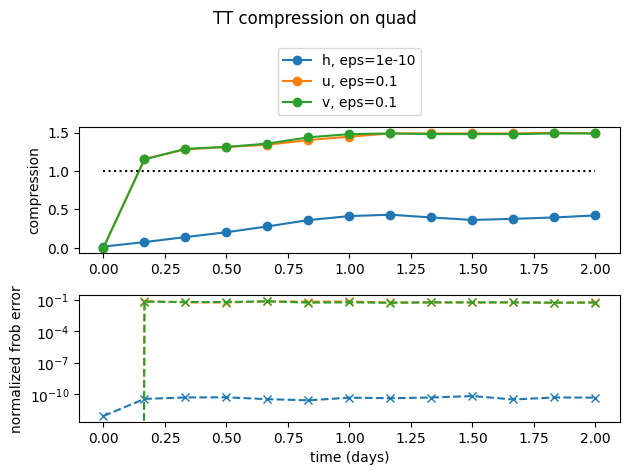

In [5]:
eps_h = 1e-10
eps_u = 1e-1
eps_v = 1e-1
data = [{'var': hh_cell[:, :], 'shape': tt_tens_shape_cell, 'eps': eps_h, 'name': 'h'},
        {'var': uu_edge[:, u_inds], 'shape': tt_tens_shape_edge_u, 'eps': eps_u, 'name': 'u'},
        {'var': uu_edge[:, v_inds], 'shape': tt_tens_shape_edge_v, 'eps': eps_v, 'name': 'v'}]
#print(f'eps_h = {eps_h}', f'eps_u = {eps_u}', f'eps_v = {eps_v}')

compression, err = get_compression_data(data)
#print(f'h_compression = {compression[0]}')
#print(f'u_compression = {compression[1]}')
#print(f'v_compression = {compression[2]}')

make_eps_plot(data, compression, err,
              'mpas',
              f'TT compression on {mesh_type}',
              f'compression_{mesh_type}_{eps_h}_{eps_u}_{eps_v}.png')

In [6]:
h_shuffle = np.copy(hh_cell[-1, :])
u_shuffle = np.copy(uu_edge[-1, u_inds])
v_shuffle = np.copy(uu_edge[-1, v_inds])

nshuffles = 100
h_final_compression = np.zeros(nshuffles)
u_final_compression = np.zeros(nshuffles)
v_final_compression = np.zeros(nshuffles)
for i in range(nshuffles):
    np.random.shuffle(h_shuffle)
    np.random.shuffle(u_shuffle)
    np.random.shuffle(v_shuffle)

    h_tt = tt.TT(h_shuffle, tt_tens_shape_cell, eps=eps_h)
    u_tt = tt.TT(u_shuffle, tt_tens_shape_edge_u, eps=eps_u)
    v_tt = tt.TT(v_shuffle, tt_tens_shape_edge_v, eps=eps_v)

    h_final_compression[i], _ = calc_compression(h_tt)
    u_final_compression[i], _ = calc_compression(u_tt)
    v_final_compression[i], _ = calc_compression(v_tt)
# END for 

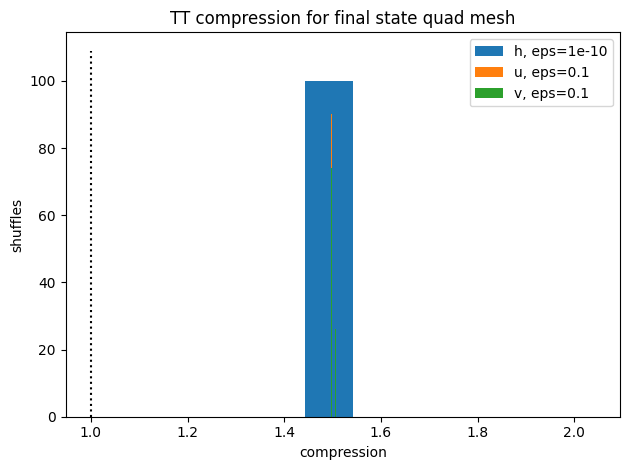

In [7]:
fig, ax = plt.subplots(tight_layout=True)
#print(u_final_compression)
#print(h_final_compression)
#print(v_final_compression)
ax.hist(h_final_compression, label=f'h, eps={eps_h}')
ax.hist(u_final_compression, label=f'u, eps={eps_u}')
ax.hist(v_final_compression, label=f'v, eps={eps_v}')
ax.plot(np.ones(int(1.1 * nshuffles)), np.arange(int(1.1 * nshuffles)), ':k')
ax.set(xlabel='compression',
       ylabel='shuffles',
       title=f'TT compression for final state {mesh_type} mesh')
ax.legend()
plt.savefig(f'compression_shuffle_{mesh_type}.png')
plt.show()

In [8]:
### sort edges, cells are already sorted on quad mesh
ds = nc.Dataset(filename)

xEdge = ds.variables['xEdge'][:]
yEdge = ds.variables['yEdge'][:]

xmin = np.min(xEdge)
xmax = np.max(xEdge)
ymin = np.min(yEdge)
ymax = np.max(yEdge)

dx = 120 * 1000
dy = 120 * 1000


# loop to sort u edges
sorted_inds_u = []
for y in np.arange(ymin + dy // 2, ymax + dy // 2, dy):
    for x in np.arange(xmin, xmax, dx):
        ind = np.where(np.logical_and(xEdge == x, yEdge == y))[0][0]
        sorted_inds_u.append(ind)
    # END for
# END for

# loop to sort v edges
sorted_inds_v = []
for y in np.arange(ymin, ymax + dy // 2, dy):
    for x in np.arange(xmin + dx // 2, xmax + dx // 2, dx):
        ind = np.where(np.logical_and(xEdge == x, yEdge == y))[0][0]
        sorted_inds_v.append(ind)
    # END for
# END for

ds.close()

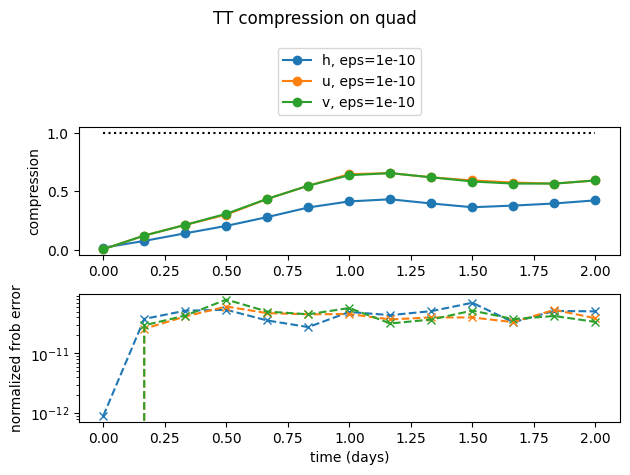

In [9]:
eps_h = 1e-10
eps_u = 1e-10
eps_v = 1e-10
data = [{'var': hh_cell, 'shape': tt_tens_shape_cell, 'eps': eps_h, 'name': 'h'},
        {'var': uu_edge[:, sorted_inds_u], 'shape': tt_tens_shape_edge_u, 'eps': eps_u, 'name': 'u'},
        {'var': uu_edge[:, sorted_inds_v], 'shape': tt_tens_shape_edge_v, 'eps': eps_v, 'name': 'v'}]
#print(f'eps_h = {eps_h}', f'eps_u = {eps_u}', f'eps_v = {eps_v}')

compression, err = get_compression_data(data)
#print(f'h_compression = {compression[0]}')
#print(f'u_compression = {compression[1]}')
#print(f'v_compression = {compression[2]}')

make_eps_plot(data, compression, err,
              'mpas',
              f'TT compression on {mesh_type}',
              f'compression_{mesh_type}_{eps_h}_{eps_u}_{eps_v}_SORTED.png')

compression_primepow_shape = compression

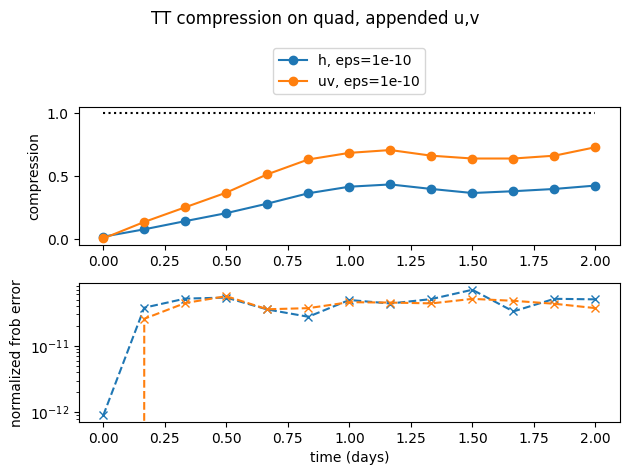

In [10]:
uv_sorted = np.append(uu_edge[:, sorted_inds_u], uu_edge[:, sorted_inds_v], axis=1)
#np.all(uv_sorted[4][0:nedges_u] == uu_edge[4, sorted_inds_u])

eps_h = 1e-10
eps_u = 1e-10
data = [{'var': hh_cell, 'shape': tt_tens_shape_cell, 'eps': eps_h, 'name': 'h'},
        {'var': uv_sorted, 'shape': tt_tens_shape_edge, 'eps': eps_u, 'name': 'uv'}]
#print(f'eps_h = {eps_h}', f'eps_u = {eps_u}', f'eps_v = {eps_v}')

compression, err = get_compression_data(data)
#print(f'h_compression = {compression[0]}')
#print(f'u_compression = {compression[1]}')
#print(f'v_compression = {compression[2]}')

make_eps_plot(data, compression, err,
              'mpas',
              f'TT compression on {mesh_type}, appended u,v',
              f'compression_{mesh_type}_{eps_h}_{eps_u}_appended.png')

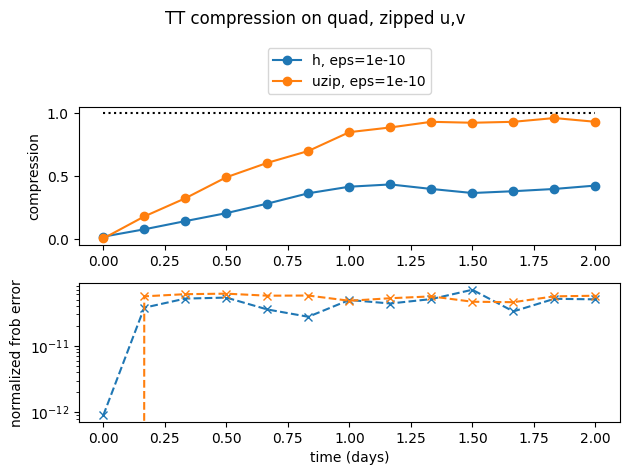

In [11]:
u_shape = uu_edge[:, sorted_inds_u].shape
v_shape = uu_edge[:, sorted_inds_v].shape
uv_zip = np.ma.empty([u_shape[0], u_shape[1] + v_shape[1]])

inds = np.arange(uv_zip.shape[1])
uv_zip[:, inds % 2 == 0] = np.ma.copy(uu_edge[:, sorted_inds_u])
uv_zip[:, inds % 2 == 1] = np.ma.copy(uu_edge[:, sorted_inds_v])

eps_h = 1e-10
eps_u = 1e-10
data = [{'var': hh_cell, 'shape': tt_tens_shape_cell, 'eps': eps_h, 'name': 'h'},
        {'var': uv_zip, 'shape': tt_tens_shape_edge, 'eps': eps_u, 'name': 'uzip'}]
#print(f'eps_h = {eps_h}', f'eps_u = {eps_u}', f'eps_v = {eps_v}')

compression, err = get_compression_data(data)
#print(f'h_compression = {compression[0]}')
#print(f'u_compression = {compression[1]}')
#print(f'v_compression = {compression[2]}')

make_eps_plot(data, compression, err,
              'mpas',
              f'TT compression on {mesh_type}, zipped u,v',
              f'compression_{mesh_type}_{eps_h}_{eps_u}_zipped.png')

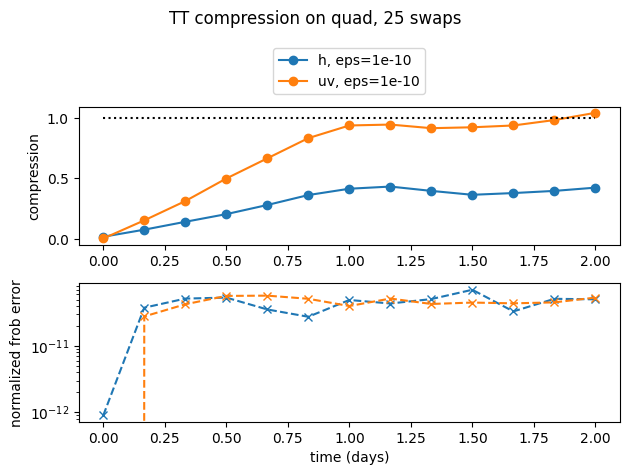

In [12]:
def rand_swap(a):
    max_ind = a.shape[1]
    ind1 = randrange(max_ind)
    ind2 = randrange(max_ind)
    a[:, [ind1, ind2]] = a[:, [ind2, ind1]]
# END rand_swap()

eps_h = 1e-10
eps_u = 1e-10
uv_shuffle = np.ma.copy(uv_sorted)

nswaps = 25
for i in range(nswaps):
    rand_swap(uv_shuffle)
# END for

data = [{'var': hh_cell, 'shape': tt_tens_shape_cell, 'eps': eps_h, 'name': 'h'},
        {'var': uv_shuffle, 'shape': tt_tens_shape_edge, 'eps': eps_u, 'name': 'uv'}]
#print(f'eps_h = {eps_h}', f'eps_u = {eps_u}', f'eps_v = {eps_v}')

compression, err = get_compression_data(data)
#print(f'h_compression = {compression[0]}')
#print(f'u_compression = {compression[1]}')
#print(f'v_compression = {compression[2]}')

make_eps_plot(data, compression, err,
              'mpas',
              f'TT compression on {mesh_type}, {nswaps} swaps',
              f'compression_{mesh_type}_{eps_h}_{eps_u}_{nswaps}swaps.png')

In [13]:
N = 334
M = ncells // N

mat_shape = [M, N]
print(mat_shape)

[168, 334]


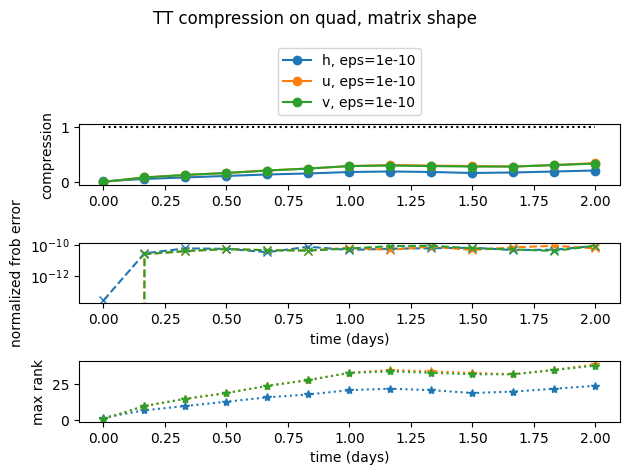

[ 2.  7. 10. 13. 16. 18. 21. 22. 21. 19. 20. 22. 24.]
[ 1. 10. 15. 19. 24. 28. 33. 35. 34. 33. 32. 35. 39.]
[ 1. 10. 15. 19. 24. 28. 33. 34. 33. 32. 32. 35. 38.]


In [14]:
eps_h = 1e-10
eps_u = 1e-10
eps_v = 1e-10
data = [{'var': hh_cell, 'shape': mat_shape, 'eps': eps_h, 'name': 'h'},
        {'var': uu_edge[:, sorted_inds_u], 'shape': mat_shape, 'eps': eps_u, 'name': 'u'},
        {'var': uu_edge[:, sorted_inds_v], 'shape': mat_shape, 'eps': eps_v, 'name': 'v'}]

compression, err, rank = get_compression_data(data, get_rank=True)
make_eps_plot(data, compression, err,
              'mpas',
              f'TT compression on {mesh_type}, matrix shape',
              f'compression_{mesh_type}_mat_shape_{eps_h}.png',
              rank=rank)
print(rank[0])
print(rank[1])
print(rank[2])

compression_mat_shape = compression

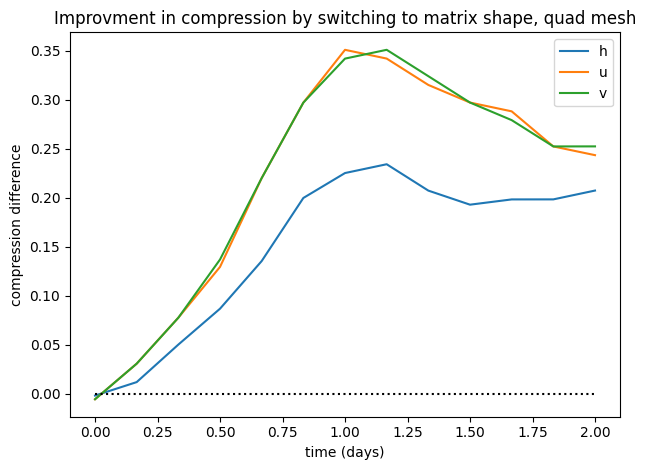

In [15]:
# NOTE -- FOR THIS PLOT TO MAKE SENSE MAKE SURE THAT
# THE EPS VALUES FOR BOTH COMPRESSION ARRAYS ARE THE SAME

time = 4 * np.arange(ntimeLevels) / 24

fig, ax  = plt.subplots(tight_layout=True)
ax.plot(time, compression_primepow_shape[0] - compression_mat_shape[0], label='h')
ax.plot(time, compression_primepow_shape[1] - compression_mat_shape[1], label='u')
ax.plot(time, compression_primepow_shape[2] - compression_mat_shape[2], label='v')
ax.plot(time, np.zeros(time.size), 'k:')
ax.set(xlabel='time (days)',
       ylabel='compression difference',
       title=f'Improvment in compression by switching to matrix shape, {mesh_type} mesh')
ax.legend()

plt.savefig(f'compression_improvement_{mesh_type}.png')
plt.show()

In [16]:
u = uu_edge[:, sorted_inds_u]
v = uu_edge[:, sorted_inds_v]

u = u.reshape([u.shape[0]] + mat_shape)
v = v.reshape([v.shape[0]] + mat_shape)
print(u.shape, v.shape)

U = np.ma.zeros([u.shape[0], 2 * u.shape[1], u.shape[2]])
print(U.shape)

U[:, np.arange(2 * u.shape[1]) % 2 == 0, :] = v[:, :, :]
U[:, np.arange(2 * u.shape[1]) % 2 == 1, :] = u[:, :, :]

(13, 168, 334) (13, 168, 334)
(13, 336, 334)


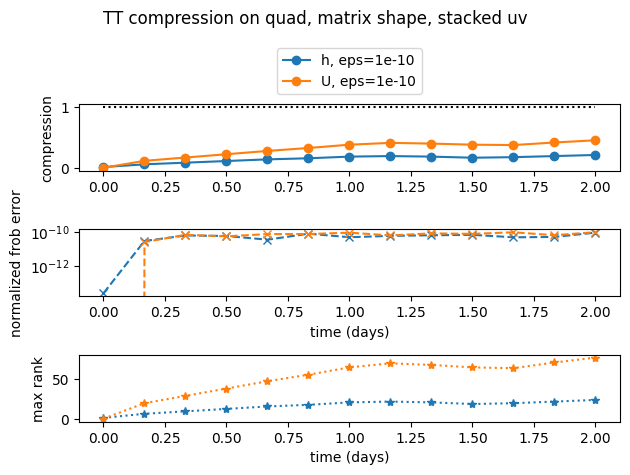

[ 2.  7. 10. 13. 16. 18. 21. 22. 21. 19. 20. 22. 24.]
[ 1. 20. 29. 38. 47. 55. 64. 69. 67. 64. 63. 70. 76.]


In [17]:
eps_h = 1e-10
eps_u = 1e-10
data = [{'var': hh_cell, 'shape': mat_shape, 'eps': eps_h, 'name': 'h'},
        {'var': U.reshape([U.shape[0], U.shape[1] * U.shape[2]]), 'shape': list(U.shape[1:]), 'eps': eps_u, 'name': 'U'}]

compression, err, rank = get_compression_data(data, get_rank=True)
make_eps_plot(data, compression, err,
              'mpas',
              f'TT compression on {mesh_type}, matrix shape, stacked uv',
              f'compression_{mesh_type}_mat_shape_{eps_h}_uv_stack.png',
              rank=rank)
print(rank[0])
print(rank[1])

In [18]:
u = uu_edge[:, sorted_inds_u]
v = uu_edge[:, sorted_inds_v]

u = u.reshape([u.shape[0]] + mat_shape)
v = v.reshape([v.shape[0]] + mat_shape)
print(u.shape, v.shape)

U = np.ma.zeros([u.shape[0], 2,  u.shape[1], u.shape[2]])
print(U.shape)

U[:, 0, :, :] = u[:, :, :]
U[:, 1, :, :] = v[:, :, :]

h = np.copy(hh_cell)
h = h.reshape([h.shape[0]] + mat_shape)

(13, 168, 334) (13, 168, 334)
(13, 2, 168, 334)


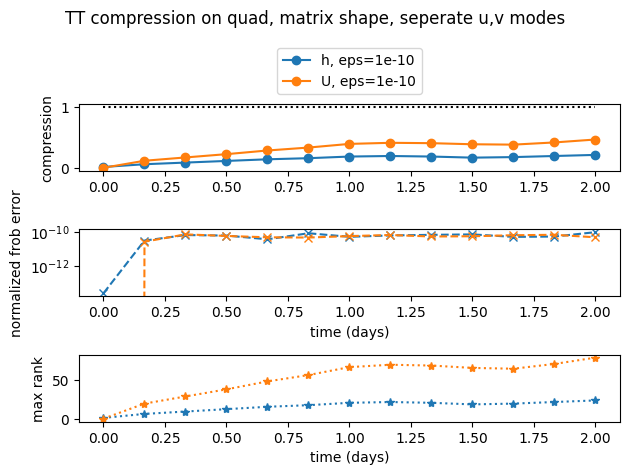

[ 2.  7. 10. 13. 16. 18. 21. 22. 21. 19. 20. 22. 24.]
[ 1. 20. 29. 38. 48. 56. 66. 69. 68. 65. 64. 70. 78.]


In [19]:
eps_h = 1e-10
eps_u = 1e-10
data = [{'var': hh_cell, 'shape': mat_shape, 'eps': eps_h, 'name': 'h'},
        {'var': U.reshape([U.shape[0], np.prod(U.shape[1:])]), 'shape': list(U.shape[1:]), 'eps': eps_u, 'name': 'U'}]

compression, err, rank = get_compression_data(data, get_rank=True)
make_eps_plot(data, compression, err,
              'mpas',
              f'TT compression on {mesh_type}, matrix shape, seperate u,v modes',
              f'compression_{mesh_type}_mat_shape_{eps_h}_uv_modes.png',
              rank=rank)
print(rank[0])
print(rank[1])

compression_nopatches = compression
err_nopatches = err
rank_nopatches = rank

factor nrows = [(2, 3), (3, 1), (7, 1)]
factor ncols = [(2, 1), (167, 1)]


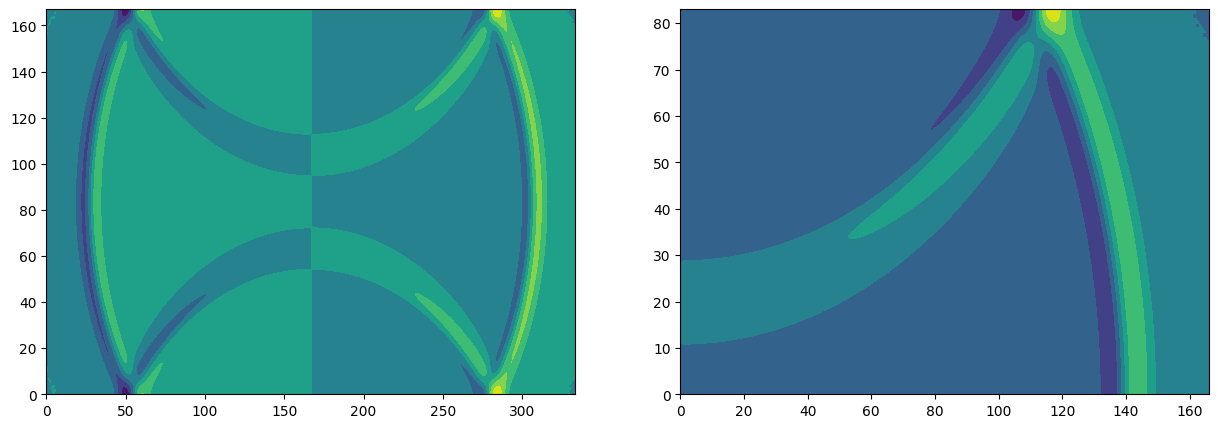

In [26]:
### example of how the foldings can give us the right patches 
### without manually labeling and ordering

nrows = mat_shape[0]
ncols = mat_shape[1]
print(f'factor nrows = {list(factorint(nrows).items())}')
print(f'factor ncols = {list(factorint(ncols).items())}')

time_ind = -1
mode_ind = 0

fig, axes = plt.subplots(1, 2, figsize=[15, 5])

npatches_row = 2
npatches_col = 2
shape = [npatches_row, mat_shape[0] // npatches_row, 
         npatches_col, mat_shape[1] // npatches_col]
patch = np.transpose(U[time_ind, mode_ind, :, :].reshape(shape), axes=(0, 2, 1, 3))

axes[0].contourf(U[time_ind, mode_ind, :, :])
axes[1].contourf(patch[0, 0, :, :])

plt.show()

(13, 2, 2, 84, 167)
(13, 2, 2, 2, 84, 167)


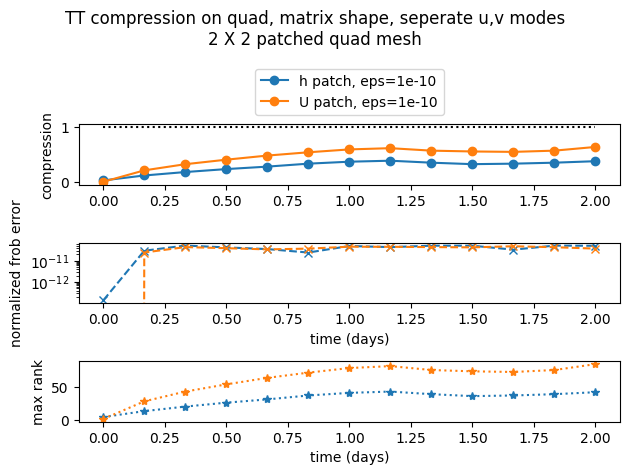

[ 4. 13. 20. 26. 31. 37. 41. 43. 39. 36. 37. 39. 42.]
[ 1. 28. 43. 54. 64. 72. 79. 82. 76. 74. 73. 76. 85.]


In [21]:
npatches_row = 2
npatches_col = 2
patch_shape = (npatches_row, mat_shape[0] // npatches_row, 
               npatches_col, mat_shape[1] // npatches_col)

# indecies are:
# 0: time
# 1: u, v
# 2: patch row
# 3: patch col
# 4: row data
# 5: col data
patch_h = np.transpose(h.reshape(h.shape[:1] + patch_shape), axes=(0, 1, 3, 2, 4))
patch_U = np.transpose(U.reshape(U.shape[:2] + patch_shape), axes=(0, 1, 2, 4, 3, 5))
print(patch_h.shape)
print(patch_U.shape)

patch_h_flattened = np.ma.array(patch_h.reshape([patch_h.shape[0], np.prod(patch_h.shape[1:])]))
patch_U_flattened = np.ma.array(patch_U.reshape([patch_U.shape[0], np.prod(patch_U.shape[1:])]))


eps_h = 1e-10
eps_u = 1e-10
data = [{'var': patch_h_flattened, 'shape': list(patch_h.shape[1:]), 'eps': eps_h, 'name': 'h patch'},
        {'var': patch_U_flattened, 'shape': list(patch_U.shape[1:]), 'eps': eps_u, 'name': 'U patch'}]

compression, err, rank = get_compression_data(data, get_rank=True)
make_eps_plot(data, compression, err,
              'mpas',
              f'TT compression on {mesh_type}, matrix shape, seperate u,v modes\n{npatches_row} X {npatches_col} patched {mesh_type} mesh',
              f'compression_{mesh_type}_patch_mat_shape_{eps_h}_uv_modes.png',
              rank=rank)
print(rank[0])
print(rank[1])

compression_patches = compression
err_patches = err
rank_patches = rank

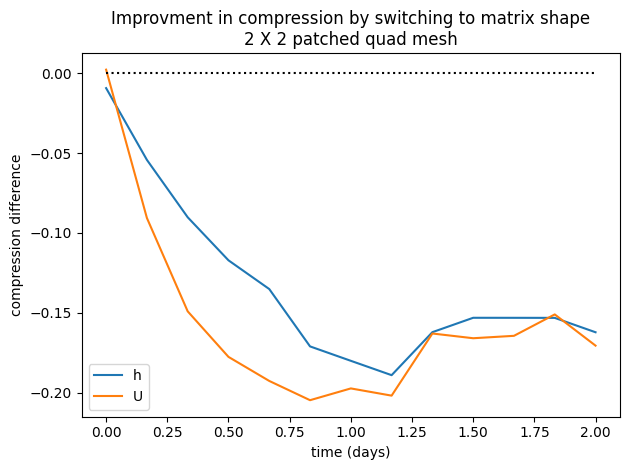

In [22]:
# NOTE -- FOR THIS PLOT TO MAKE SENSE MAKE SURE THAT
# THE EPS VALUES FOR BOTH COMPRESSION ARRAYS ARE THE SAME

time = 4 * np.arange(ntimeLevels) / 24

fig, ax  = plt.subplots(tight_layout=True)
ax.plot(time, compression_nopatches[0] - compression_patches[0], label='h')
ax.plot(time, compression_nopatches[1] - compression_patches[1], label='U')
ax.plot(time, np.zeros(time.size), 'k:')
ax.set(xlabel='time (days)',
       ylabel='compression difference',
       title=f'Improvment in compression by switching to matrix shape\n{npatches_row} X {npatches_col} patched {mesh_type} mesh')
ax.legend()

plt.savefig(f'compression_improvement_patches_{mesh_type}.png')
plt.show()